# Various experiments for GNN

In [1]:
from pathlib import Path
from typing import Any, Dict, List, Optional, Tuple
import json, math, time, random, re, glob, os, itertools
import numpy as np
import pandas as pd

USE_DIRECTML = False

import torch
device = torch.device('cpu')
if not USE_DIRECTML and torch.cuda.is_available():
    device = torch.device('cuda')
elif USE_DIRECTML:
    try:
        import torch_directml
        device = torch_directml.device()
        print("Using DirectML:", device)
    except Exception as e:
        print("DirectML not available, falling back to CPU:", e)
        device = torch.device('cpu')

import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, Subset
from torch_geometric.data import Data
from torch_geometric.loader import DataLoader
from torch_geometric.nn import SAGEConv, GraphNorm, global_mean_pool
from torch_geometric.utils import dropout_edge

import matplotlib.pyplot as plt

In [2]:
NUC2ID = {'A':1, 'C':2, 'G':3, 'T':4, 'N':5}

def seq_to_tokens(seq: str) -> torch.LongTensor:
    return torch.tensor([NUC2ID.get(c, 5) for c in seq], dtype=torch.long)

def tokens_to_onehot(tokens: torch.LongTensor, num_classes: int = 6):
    N, K = tokens.shape
    classes = torch.arange(num_classes, device=tokens.device).view(1, 1, num_classes)
    return (tokens.unsqueeze(-1) == classes).float()

def _safe_get(d: Dict[str, Any], key: str, default):
    v = d.get(key, default)
    return default if v is None else v

ID2NUC = {v:k for k,v in NUC2ID.items()}

def tokens_to_seq(tokens: torch.LongTensor) -> str:
    return "".join(ID2NUC.get(int(t), "N") for t in tokens.tolist())


In [3]:
class HyperbubbleDataset(Dataset):
    """
    Minimal GNN-ready dataset with token sequences for CNN encoding.
    """
    def __init__(self, files: List[str]):
        self.files = [Path(p) for p in files]
        self.records: List[Dict[str, Any]] = []
        for fp in self.files:
            with fp.open("r") as fh:
                for line in fh:
                    line = line.strip()
                    if not line:
                        continue
                    try:
                        self.records.append(json.loads(line))
                    except json.JSONDecodeError:
                        continue

    def __len__(self) -> int:
        return len(self.records)

    def _build_graph(self, rec: Dict[str, Any]) -> Data:
        node_seqs: Dict[str, int] = {}
        node_covs: List[float] = []

        def ensure_node(seq: str, cov: Optional[float]=None) -> int:
            if seq not in node_seqs:
                node_seqs[seq] = len(node_seqs)
                node_covs.append(float(cov) if cov is not None else 0.0)
            else:
                i = node_seqs[seq]
                if cov is not None and node_covs[i] == 0:
                    node_covs[i] = float(cov)
            return node_seqs[seq]

        start_seq = rec["start_seq"]
        end_seq   = rec["end_seq"]

        for n in _safe_get(rec,"nodes",[]): ensure_node(n["seq"], n.get("cov"))
        for n in _safe_get(rec,"upstream_nodes",[]): ensure_node(n["seq"], n.get("cov"))
        for n in _safe_get(rec,"downstream_nodes",[]): ensure_node(n["seq"], n.get("cov"))
        for n in _safe_get(rec,"inside_nodes",[]):
            if isinstance(n,dict) and "seq" in n:
                ensure_node(n["seq"], n.get("cov"))

        ensure_node(start_seq)
        ensure_node(end_seq)

        edge_src, edge_dst, edge_attr = [], [], []
        edge_list = _safe_get(rec, "all_edges", None)
        if not edge_list:
            edge_list = _safe_get(rec, "edges", [])
        for e in edge_list:
            u = ensure_node(e["source_seq"])
            v = ensure_node(e["target_seq"])
            edge_src.append(u)
            edge_dst.append(v)
            edge_attr.append([
                float(e.get("len_nodes",0)),
                float(e.get("len_bp",0)),
                float(e.get("cov_min",0)),
                float(e.get("cov_mean",0.0))
            ])

        # -----------------------------
        # NORMALIZATION
        # -----------------------------
        def lognorm(arr):
            if len(arr) == 0:
                return arr
            x = np.log1p(np.asarray(arr, dtype=np.float32))
            m = x.mean()
            s = x.std() + 1e-6
            return (x - m) / s

        node_covs = lognorm(node_covs)

        if edge_attr:
            ea = np.asarray(edge_attr, dtype=np.float32)
            for c in range(ea.shape[1]):
                ea[:, c] = lognorm(ea[:, c])
            edge_attr = ea.tolist()

        # -----------------------------

        node_order = [None]*len(node_seqs)
        for s,i in node_seqs.items():
            node_order[i]=s

        # store tokens only, CNN handles one-hot
        seq_tokens = torch.stack([seq_to_tokens(s) for s in node_order], dim=0)
        x_cov = torch.tensor(node_covs, dtype=torch.float32).unsqueeze(1)

        start_idx = torch.tensor(node_seqs[start_seq])
        end_idx   = torch.tensor(node_seqs[end_seq])

        edge_index = torch.tensor([edge_src, edge_dst], dtype=torch.long)
        edge_attr  = torch.tensor(edge_attr, dtype=torch.float32) if edge_attr else torch.zeros((0,4))

        num_edges = edge_index.size(1)
        y_edge_mask = torch.zeros(num_edges, dtype=torch.long)
        label_path_idx = -1

        paths_list = _safe_get(rec,"paths",[])
        lp = rec.get("label_path")
        if lp is not None and 0 <= lp < len(paths_list):
            label_path_idx = lp
            if num_edges > 0:
                y_edge_mask[torch.tensor(paths_list[lp], dtype=torch.long)] = 1

        data = Data(
            seq_tokens=seq_tokens,
            x_cov=x_cov,
            edge_index=edge_index,
            edge_attr=edge_attr,
            start_idx=start_idx,
            end_idx=end_idx,
            num_nodes=seq_tokens.size(0),
            y_edge_mask=y_edge_mask,
            label_path_idx=torch.tensor(label_path_idx),
        )
        if "bubble_id" in rec:
            data.bubble_id = torch.tensor(rec["bubble_id"])
        if "k" in rec:
            data.k = torch.tensor(rec["k"])
        return data

    def __getitem__(self, idx: int) -> Data:
        return self._build_graph(self.records[idx])

In [4]:
# [DISCOVERY] automatyczne wyszukiwanie plików z bąblami po pokryciu i genomie

# katalogi, w których leżą dane
SEARCH_DIRS = [
    Path("lower_cov_data"),
    Path(".")
]

def discover_base_datasets_for_cov(coverage: int) -> Dict[str, str]:
    """
    Znajdź wszystkie pliki w formacie:
        {genome_id}_dataset_cov{coverage}_ratio_lt_1.5.jsonl
    w katalogach z SEARCH_DIRS.

    Zwraca słownik:
        {genome_id: pełna_ścieżka_do_pliku}
    """
    pattern = f"*dataset_cov{coverage}_ratio_lt_3.5_all_edges.jsonl"
    candidates: List[Path] = []

    for d in SEARCH_DIRS:
        if not d.is_dir():
            continue
        candidates.extend(d.glob(pattern))

    # unikalne + posortowane
    unique = sorted({p.resolve() for p in candidates})

    if not unique:
        raise FileNotFoundError(
            f"Nie znaleziono plików dla pokrycia {coverage} (wzorzec: {pattern}) "
            f"w katalogach: {', '.join(str(d) for d in SEARCH_DIRS)}"
        )

    mapping: Dict[str, str] = {}
    for p in unique:
        name = p.name
        # genome_id = wszystko przed '_dataset_cov'
        genome_id = name.split("_dataset_cov")[0]
        mapping[genome_id] = str(p)

    print(f"[discover_base_datasets_for_cov] coverage={coverage} -> znaleziono {len(mapping)} genomów:")
    return mapping


COVERAGES = [20]
COV_TO_FILES = {cov: discover_base_datasets_for_cov(cov) for cov in COVERAGES}

# zbiór wszystkich genomów, jakie realnie istnieją w danych
ALL_GENOMES = sorted(set().union(*[m.keys() for m in COV_TO_FILES.values()]))
print("ALL_GENOMES:", ALL_GENOMES)


# Keep only labeled samples
def labeled_subset(ds):
    labeled_indices = []
    for i in range(len(ds)):
        d = ds[i]
        lp = int(d.label_path_idx.item()) if hasattr(d, "label_path_idx") else -1
        if lp >= 0:
            labeled_indices.append(i)
    return Subset(ds, labeled_indices)


[discover_base_datasets_for_cov] coverage=20 -> znaleziono 3 genomów:
ALL_GENOMES: ['Ecoli', 'klebsiella', 'salmonella']


In [5]:
class PositionalEncoding1D(nn.Module):
    def __init__(self, K, dim):
        super().__init__()
        self.pe = nn.Parameter(torch.randn(1, K, dim) * 0.02)

    def forward(self, x):
        return x + self.pe


class HyperbubbleGNN(nn.Module):
    """
    CNN encoder + Positional Encoding + 2× SAGEConv + Global Graph Embedding + MLP classifier
    with DropEdge regularization, BatchNorm, and residual GNN connections.
    """
    def __init__(
        self,
        vocab_size=6,
        cnn_channels=32,
        gcn_hidden=64,
        edge_hidden=64,
        edge_feat_dim=4,
        dropout=0.0,
        K=21,
        dropedge_p=0.2,
    ):
        super().__init__()

        self.dropedge_p = dropedge_p

        # Positional encoding
        self.posenc = PositionalEncoding1D(K, vocab_size)

        # CNN encoder
        self.cnn = nn.Conv1d(vocab_size, cnn_channels, kernel_size=3, padding=1)
        self.cnn_bn = nn.BatchNorm1d(cnn_channels)      # <<< NEW

        # Node feature dimension
        self.node_in = cnn_channels + 1

        # GNN layers
        self.gcn1 = SAGEConv(self.node_in, gcn_hidden, root_weight=True)
        self.gcn2 = SAGEConv(gcn_hidden, gcn_hidden, root_weight=True)

        # Norms
        self.norm1 = GraphNorm(gcn_hidden)
        self.norm2 = GraphNorm(gcn_hidden)

        self.dropout = nn.Dropout(dropout)
        self.gcn_hidden = gcn_hidden

        # MLP classifier
        self.edge_mlp = nn.Sequential(
            nn.Linear(2 * gcn_hidden + edge_feat_dim + gcn_hidden, edge_hidden),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(edge_hidden, 1),
        )

    # ------------------------------------------------------------
    def encode_nodes(self, seq_tokens, x_cov):
        onehot = tokens_to_onehot(seq_tokens)   # [N,K,6]
        x = self.posenc(onehot)                 # [N,K,6]
        x = x.permute(0, 2, 1)                  # [N,6,K]

        H = F.relu(self.cnn(x))                 # [N,C,K]
        H = H.mean(dim=2)                       # [N,C]

        H = self.cnn_bn(H)                      # <<< NEW BatchNorm

        return torch.cat([H, x_cov], dim=1)     # [N,C+1]

    # ------------------------------------------------------------
    def forward(self, data):
        X0 = self.encode_nodes(data.seq_tokens, data.x_cov)

        # DropEdge
        edge_index, _ = dropout_edge(
            data.edge_index,
            p=self.dropedge_p,
            training=self.training
        )

        # -------------------------
        # GNN + Residual block
        # -------------------------

        # First layer
        H1 = F.relu(self.gcn1(X0, edge_index))
        H1 = self.norm1(H1)
        H1 = self.dropout(H1)

        # Second layer
        H2 = F.relu(self.gcn2(H1, edge_index))
        H2 = self.norm2(H2)
        H2 = self.dropout(H2)

        # Residual connection
        H = H1 + H2                                # <<< NEW residual connection

        # -------------------------
        # Global graph embedding
        # -------------------------
        batch = data.batch
        graph_emb = global_mean_pool(H, batch)

        u, v = data.edge_index
        batch_edge = batch[u]
        GE = graph_emb[batch_edge]

        # Edge features
        U = H[u]
        V = H[v]

        if hasattr(data, "edge_attr") and data.edge_attr.numel() > 0:
            EA = data.edge_attr
        else:
            EA = H.new_zeros((u.numel(), 5))

        feats = torch.cat([U, V, EA, GE], dim=1)

        logits = self.edge_mlp(feats).squeeze(-1)
        return logits


In [6]:
def _num_graphs_in_batch(node_batch: torch.Tensor) -> int:
    return int(node_batch.max().item()) + 1 if node_batch.numel() else 0

def _edge_batch_from_nodes(node_batch: torch.Tensor, edge_src: torch.Tensor) -> torch.Tensor:
    return node_batch[edge_src] if edge_src.numel() else edge_src.new_zeros((0,), dtype=torch.long)

def _collect_decisions_by_labeled_sources(data, g: int, u: torch.Tensor, edge_batch: torch.Tensor):
    """
    Return list of (cand_idx_tensor, gold_pos_tensor) for EVERY decision node
    whose source node appears on the labeled path. This is orientation-agnostic.
    """
    y = data.y_edge_mask
    lab_eidx = (y == 1).nonzero(as_tuple=False).view(-1)
    lab_eidx = lab_eidx[edge_batch[lab_eidx] == g]
    if lab_eidx.numel() == 0:
        return []

    labeled_sources = torch.unique(u[lab_eidx])

    decisions = []
    for s in labeled_sources.tolist():
        mask = (edge_batch == g) & (u == s)
        cand_idx = mask.nonzero(as_tuple=False).view(-1)
        if cand_idx.numel() < 2:
            continue
        y_here = y[cand_idx]
        gold_pos = (y_here == 1).nonzero(as_tuple=False).view(-1)
        if gold_pos.numel() == 1:
            decisions.append((cand_idx, gold_pos.view(1)))
    return decisions



def _cpu_state_dict(sd):
    return {k: v.detach().cpu().clone() for k, v in sd.items()}

best_ckpt = {
    "epoch": 0,
    "dec_acc": -1.0,
    "bub_acc": -1.0,
    "state_dict": None,
}

def _is_better(bub_acc, dec_acc, best):
    if bub_acc > best["bub_acc"]:
        return True
    if bub_acc == best["bub_acc"] and dec_acc > best["dec_acc"]:
        return True
    return False

@torch.no_grad()
def eval_choice_all(model, loader, device):
    model.eval()
    total_decisions, correct_decisions = 0, 0
    total_bubbles, correct_bubbles = 0, 0

    for data in loader:
        data = data.to(device)
        logits = model(data)
        if logits.numel() == 0:
            continue

        u = data.edge_index[0]
        node_batch = data.batch
        edge_batch = _edge_batch_from_nodes(node_batch, u)
        num_graphs = _num_graphs_in_batch(node_batch)

        for g in range(num_graphs):
            decisions = _collect_decisions_by_labeled_sources(data, g, u, edge_batch)
            if not decisions:
                continue
            total_bubbles += 1

            all_correct = True
            for cand_idx, gold_pos in decisions:
                pred = logits[cand_idx].argmax().item()
                ok = int(pred == gold_pos.item())
                correct_decisions += ok
                total_decisions += 1
                all_correct &= bool(ok)

            correct_bubbles += int(all_correct)

    dec_acc = correct_decisions / max(total_decisions, 1)
    bub_acc = correct_bubbles / max(total_bubbles, 1)
    print(f"[choice-eval] decisions={total_decisions} acc_dec={dec_acc:.3f} | bubbles={total_bubbles} acc_bub={bub_acc:.3f}")
    return dec_acc, bub_acc

In [7]:
def set_seed(seed: int):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)

def split_train_val(n: int, val_frac: float, seed: int):
    rng = np.random.default_rng(seed)
    order = np.arange(n)
    rng.shuffle(order)
    n_val = int(round(val_frac * n))
    val_idx = order[:n_val]
    tr_idx  = order[n_val:]
    return tr_idx.tolist(), val_idx.tolist()

def count_params(model):
    return sum(p.numel() for p in model.parameters() if p.requires_grad)


def _num_graphs_in_batch(node_batch: torch.Tensor) -> int:
    return int(node_batch.max().item()) + 1 if node_batch.numel() else 0

def _edge_batch_from_nodes(node_batch: torch.Tensor, edge_src: torch.Tensor) -> torch.Tensor:
    return node_batch[edge_src] if edge_src.numel() else edge_src.new_zeros((0,), dtype=torch.long)

def _collect_decisions_by_labeled_sources(data, g: int, u: torch.Tensor, edge_batch: torch.Tensor):
    """
    Zwraca listę (cand_idx, gold_pos) dla każdego węzła źródłowego w grafie g,
    dla którego istnieje decyzja (zaznaczone krawędzie y_edge_mask==1).
    """
    y = data.y_edge_mask
    lab_eidx = (y == 1).nonzero(as_tuple=False).view(-1)
    lab_eidx = lab_eidx[edge_batch[lab_eidx] == g]
    if lab_eidx.numel() == 0:
        return []

    labeled_sources = torch.unique(u[lab_eidx])

    decisions = []
    for s in labeled_sources.tolist():
        mask = (edge_batch == g) & (u == s)
        cand_idx = mask.nonzero(as_tuple=False).view(-1)
        if cand_idx.numel() < 2:
            continue
        y_here = y[cand_idx]
        gold_pos = (y_here == 1).nonzero(as_tuple=False).view(-1)
        if gold_pos.numel() == 1:
            decisions.append((cand_idx, gold_pos.view(1)))
    return decisions

@torch.no_grad()
def _candidate_sets(data, logits: torch.Tensor):
    """
    Zwraca listę (cand_idx [M], gold_pos [1], g) dla każdej decyzji w batchu.
    """
    u = data.edge_index[0]
    node_batch = (
        data.batch if hasattr(data, "batch")
        else torch.zeros(data.num_nodes, dtype=torch.long, device=logits.device)
    )
    edge_batch = _edge_batch_from_nodes(node_batch, u)
    num_graphs = _num_graphs_in_batch(node_batch)
    out = []
    for g in range(num_graphs):
        decisions = _collect_decisions_by_labeled_sources(data, g, u, edge_batch)
        for cand_idx, gold_pos in decisions:
            out.append((cand_idx, gold_pos, g))
    return out

def decision_ce_loss_from_batch(logits: torch.Tensor, data, reduction: str = "mean"):
    """
    Cross-entropy liczona po decyzjach (candidate sets).
    """
    if logits.numel() == 0:
        return logits.new_zeros(()), 0
    losses, decisions = [], 0
    u = data.edge_index[0]
    node_batch = (
        data.batch if hasattr(data, "batch")
        else torch.zeros(data.num_nodes, dtype=torch.long, device=logits.device)
    )
    edge_batch = _edge_batch_from_nodes(node_batch, u)
    num_graphs = _num_graphs_in_batch(node_batch)

    for g in range(num_graphs):
        cands = _collect_decisions_by_labeled_sources(data, g, u, edge_batch)
        for cand_idx, gold_pos in cands:
            cand_logits = logits[cand_idx]     # [M]
            target = gold_pos.view(1)          # [1]
            losses.append(F.cross_entropy(cand_logits.unsqueeze(0), target))
            decisions += 1

    if decisions == 0:
        return logits.new_zeros(()), 0
    loss = torch.stack(losses)
    return (loss.mean() if reduction == "mean" else loss.sum()), decisions


@torch.no_grad()
def eval_rich_metrics(model, loader, device) -> Dict[str, float]:
    """
    Minimalny zestaw metryk:
      - acc_dec   : dokładność decyzji (wybór ścieżki)
      - acc_bub   : dokładność bąbli (wszystkie decyzje w bąblu poprawne)
      - precision_dec, recall_dec, f1_dec : metryki binarne dla decyzji
      - brier     : błąd Briera dla prawdopodobieństwa poprawnej ścieżki

    Wszystko w oparciu o candidate sets, bez ECE / ROC / PR-AUC / MRR.
    """
    model.eval()
    dec_correct, dec_total = 0, 0
    bubble_ok = {}  # key: (id(data), g)

    confs_gold = []   # p(model poprawny) dla poprawnej ścieżki (gold)
    labels_gold = []  # 1/0 czy decyzja faktycznie poprawna

    y_true_dec = []   # 1 jeśli decyzja poprawna
    y_pred_dec = []   # 1 jeśli model jest "pewny" (p(pred) >= 0.5)

    for data in loader:
        data = data.to(device)
        logits = model(data)
        if logits.numel() == 0:
            continue

        for cand_idx, gold_pos, g in _candidate_sets(data, logits):
            cand_logits = logits[cand_idx]              # [M]
            probs = F.softmax(cand_logits, dim=0)
            pred = int(torch.argmax(cand_logits).item())
            gold = int(gold_pos.item())

            ok = int(pred == gold)
            dec_total += 1
            dec_correct += ok

            key = (id(data), int(g))
            bubble_ok.setdefault(key, True)
            bubble_ok[key] = bubble_ok[key] and bool(ok)

            # Brier: prawdopodobieństwo poprawnej ścieżki
            conf_gold = float(probs[gold].item())
            confs_gold.append(conf_gold)
            labels_gold.append(float(ok))

            # klasyfikacja binarna dla precision/recall/F1:
            #   true = decyzja poprawna
            #   pred = pewny (p(pred) >= 0.5)
            y_true_dec.append(float(ok))
            conf_pred = float(probs[pred].item())
            y_pred_dec.append(1.0 if conf_pred >= 0.5 else 0.0)

    acc_dec = dec_correct / max(dec_total, 1)

    bub_total = len(bubble_ok)
    bub_correct = sum(1 for ok in bubble_ok.values() if ok)
    acc_bub = bub_correct / max(bub_total, 1)

    # Brier
    confs_gold = np.array(confs_gold, dtype=np.float64)
    labels_gold = np.array(labels_gold, dtype=np.float64)
    if confs_gold.size:
        brier = float(((confs_gold - labels_gold) ** 2).mean())
    else:
        brier = float("nan")

    # precision / recall / F1 dla decyzji
    y_true_dec = np.array(y_true_dec, dtype=np.int32)
    y_pred_dec = np.array(y_pred_dec, dtype=np.int32)
    if y_true_dec.size:
        tp = int(((y_true_dec == 1) & (y_pred_dec == 1)).sum())
        fp = int(((y_true_dec == 0) & (y_pred_dec == 1)).sum())
        fn = int(((y_true_dec == 1) & (y_pred_dec == 0)).sum())

        precision_dec = tp / max(tp + fp, 1)
        recall_dec    = tp / max(tp + fn, 1)
        if precision_dec + recall_dec > 0:
            f1_dec = 2 * precision_dec * recall_dec / (precision_dec + recall_dec)
        else:
            f1_dec = 0.0
    else:
        precision_dec = recall_dec = f1_dec = float("nan")

    return {
        "acc_dec": acc_dec,
        "acc_bub": acc_bub,
        "precision_dec": precision_dec,
        "recall_dec": recall_dec,
        "f1_dec": f1_dec,
        "brier": brier,
        "decisions": dec_total,
        "bubbles": bub_total,
    }


def train_one_epoch(model, loader, device, optimizer):
    model.train()
    total_loss, total_decisions = 0.0, 0
    for data in loader:
        data = data.to(device)
        optimizer.zero_grad(set_to_none=True)
        logits = model(data)
        loss, ndec = decision_ce_loss_from_batch(logits, data, reduction="mean")
        if ndec == 0:
            continue
        loss.backward()
        optimizer.step()
        total_loss += float(loss.item()) * ndec
        total_decisions += ndec
    return total_loss / max(total_decisions, 1)


def fit_variant(build_model_fn,
                train_loader,
                val_loader,
                device,
                out_ckpt: Path,
                epochs=20,
                lr=1e-3,
                weight_decay=0,
                patience=5,
                seed=42,
                print_every=5,
                early_stop=True):

    set_seed(seed)
    model = build_model_fn().to(device)
    opt = torch.optim.AdamW(model.parameters(), lr=lr, weight_decay=weight_decay)

    best_val = -1
    best_state = None
    waited = 0
    history = []

    train_losses = []
    val_losses   = []
    val_accs     = []

    for ep in range(1, epochs + 1):

        # --- TRAIN ---
        tr_loss = train_one_epoch(model, train_loader, device, opt)

        # --- VAL METRICS ---
        val_stats = eval_rich_metrics(model, val_loader, device)

        # compute val loss (using existing CE per decision)
        model.eval()
        total_vloss = 0.0
        total_vdec = 0
        with torch.no_grad():
            for data in val_loader:
                data = data.to(device)
                logits = model(data)
                vloss, vdec = decision_ce_loss_from_batch(logits, data, reduction="mean")
                if vdec == 0:
                    continue
                total_vloss += float(vloss.item()) * vdec
                total_vdec += vdec

        val_loss = total_vloss / max(total_vdec, 1)

        # --- logging ---
        history.append({
            "epoch": ep,
            "train_loss": tr_loss,
            "val_loss": val_loss,
            **val_stats
        })

        train_losses.append(tr_loss)
        val_losses.append(val_loss)
        val_accs.append(val_stats["acc_dec"])

        if (ep % print_every == 0) or ep == 1:
            print(
                f"[ep {ep:03d}] train_loss={tr_loss:.4f}  "
                f"val_loss={val_loss:.4f}  "
                f"val_dec={val_stats['acc_dec']:.4f}"
            )

        # --- early stopping ---
        metric = val_stats["acc_dec"]
        if metric > best_val:
            best_val = metric
            best_state = {k: v.detach().cpu().clone() for k, v in model.state_dict().items()}
            waited = 0
        else:
            waited += 1

        if early_stop and waited >= patience:
            break

    # fallback if no best found
    if best_state is None:
        best_state = model.state_dict()

    torch.save(best_state, out_ckpt)
    return best_state, pd.DataFrame(history)



In [8]:
OUTDIR = Path("sweep_test_multiple_runs_per_fold"); OUTDIR.mkdir(exist_ok=True, parents=True)
N_REPEATS = 5 
KEEP_SPLIT_FIXED_PER_FOLD = True

SEED = random.randint(1, 100)
BATCH_SIZE = 64
NUM_WORKERS = 0
EPOCHS = 50
PATIENCE = 200
LR = 1e-3
WEIGHT_DECAY = 1e-3
VAL_FRAC = 0.2

CHANNEL_GRID = [8,16,32,64]
GCN_HIDDEN_GRID = [8,16,32,64,128,256]
EDGE_HIDDEN_GRID = [8,16,32,64,128,256]
74
dropout = 0.2
edge_dropout = 0.3

PRINT_EVERY = 10

COVERAGE_SWEEP = 20
GENOME_TO_PATH = COV_TO_FILES[COVERAGE_SWEEP]
GENOMES = sorted(GENOME_TO_PATH.keys())
print("Genomy używane w sweepie architektur:", GENOMES)

OUTDIR = Path("sweep_from_paths_more_genomes")
OUTDIR.mkdir(parents=True, exist_ok=True)



Genomy używane w sweepie architektur: ['Ecoli', 'klebsiella', 'salmonella']


In [9]:
# rows = []
# set_seed(SEED)

# def metrics_cols_from_df(df: pd.DataFrame):
#     # include numeric metrics but exclude identifiers
#     exclude = {"coverage", "fold", "repeat", "params"}
#     id_like = {"variant", "test_genome"}
#     numeric = [c for c in df.columns if pd.api.types.is_numeric_dtype(df[c])]
#     return [c for c in numeric if (c not in exclude) and (c not in id_like)]

# for ch in CHANNEL_GRID:
#     for gh in GCN_HIDDEN_GRID:
#         for eh in EDGE_HIDDEN_GRID:
#             variant = f"emb{ch}_g{gh}_e{eh}"
#             print(f"\n=== SWEEP: {variant} ===")

#             def build_model():
#                 return HyperbubbleGNN(
#                     vocab_size=6,
#                     cnn_channels=ch,
#                     gcn_hidden=gh,
#                     edge_hidden=eh,
#                     edge_feat_dim=4,
#                     dropout=dropout,
#                     dropedge_p=edge_dropout,
#                 )

#             # count params once per variant (same across folds/repeats)
#             _tmp_model = build_model().to(device)
#             variant_params = count_params(_tmp_model)
#             del _tmp_model

#             for fold, test_genome in enumerate(GENOMES, start=1):
#                 test_paths  = [GENOME_TO_PATH[test_genome]]
#                 train_paths = [GENOME_TO_PATH[g] for g in GENOMES if g != test_genome]

#                 # Build datasets once per fold (reused across repeats)
#                 train_full = HyperbubbleDataset(train_paths)
#                 test_full  = HyperbubbleDataset(test_paths)

#                 train_lab = labeled_subset(train_full)
#                 test_lab  = labeled_subset(test_full)

#                 if len(train_lab) == 0 or len(test_lab) == 0:
#                     print(f"[WARN] brak etykiet dla test_genome={test_genome}, pomijam fold")
#                     continue

#                 # Fixed split per fold (optional)
#                 split_seed = (SEED + 10_000 * fold) if KEEP_SPLIT_FIXED_PER_FOLD else None
#                 if split_seed is None:
#                     # we will recompute split per repeat below
#                     tr_idx_base, va_idx_base = None, None
#                 else:
#                     tr_idx_base, va_idx_base = split_train_val(len(train_lab), VAL_FRAC, split_seed)

#                 print(
#                     f"[{variant}] fold={fold} test={test_genome} "
#                     f"(train_lab={len(train_lab)} test={len(test_lab)}) repeats={N_REPEATS}"
#                 )

#                 for repeat in range(1, N_REPEATS + 1):
#                     # per-repeat seed (changes init + dataloader shuffling, etc.)
#                     run_seed = SEED + (100_000 * fold) + (1_000 * repeat) + (hash(variant) % 997)

#                     set_seed(run_seed)

#                     # split: either fixed per fold, or varies per repeat
#                     if KEEP_SPLIT_FIXED_PER_FOLD:
#                         tr_idx, va_idx = tr_idx_base, va_idx_base
#                     else:
#                         tr_idx, va_idx = split_train_val(len(train_lab), VAL_FRAC, run_seed)

#                     train_ds = Subset(train_lab, tr_idx)
#                     val_ds   = Subset(train_lab, va_idx)
#                     test_ds  = test_lab

#                     # Use a seeded generator for deterministic shuffling (num_workers=0)
#                     g = torch.Generator()
#                     g.manual_seed(run_seed)

#                     train_loader = DataLoader(
#                         train_ds, batch_size=BATCH_SIZE, shuffle=True,
#                         num_workers=NUM_WORKERS, generator=g
#                     )
#                     val_loader = DataLoader(
#                         val_ds, batch_size=BATCH_SIZE, shuffle=False,
#                         num_workers=NUM_WORKERS
#                     )
#                     test_loader = DataLoader(
#                         test_ds, batch_size=BATCH_SIZE, shuffle=False,
#                         num_workers=NUM_WORKERS
#                     )

#                     print(
#                         f"  -> run fold={fold} test={test_genome} repeat={repeat}/{N_REPEATS} "
#                         f"(train={len(train_ds)} val={len(val_ds)} test={len(test_ds)}) seed={run_seed}"
#                     )

#                     ckpt = OUTDIR / f"{variant}_cov{COVERAGE_SWEEP}_fold{fold}_{test_genome}_rep{repeat}.pth"
#                     log_csv = OUTDIR / f"{variant}_cov{COVERAGE_SWEEP}_fold{fold}_{test_genome}_rep{repeat}_history.csv"

#                     best_state, hist_df = fit_variant(
#                         build_model_fn=build_model,
#                         train_loader=train_loader,
#                         val_loader=val_loader,
#                         device=device,
#                         out_ckpt=ckpt,
#                         epochs=EPOCHS,
#                         lr=LR,
#                         weight_decay=WEIGHT_DECAY,
#                         patience=PATIENCE,
#                         seed=run_seed,
#                         print_every=PRINT_EVERY,
#                         early_stop=True,
#                     )
#                     hist_df["variant"]     = variant
#                     hist_df["coverage"]    = COVERAGE_SWEEP
#                     hist_df["fold"]        = fold
#                     hist_df["test_genome"] = test_genome
#                     hist_df["repeat"]      = repeat
#                     hist_df["seed"]        = run_seed
#                     hist_df.to_csv(log_csv, index=False)

#                     model = build_model().to(device)
#                     model.load_state_dict(best_state)
#                     model.eval()

#                     stats = eval_rich_metrics(model, test_loader, device)
#                     stats.update({
#                         "variant": variant,
#                         "coverage": COVERAGE_SWEEP,
#                         "fold": fold,
#                         "test_genome": test_genome,
#                         "repeat": repeat,
#                         "seed": run_seed,
#                         "params": variant_params,
#                     })
#                     rows.append(stats)

#                     print(
#                         f"    [TEST] {variant} | fold={fold} | test={test_genome} | rep={repeat} -> "
#                         f"acc_bub={stats['acc_bub']:.3f}  "
#                         f"acc_dec={stats['acc_dec']:.3f}  "
#                         f"F1_dec={stats['f1_dec']:.3f}"
#                     )

# df_raw = pd.DataFrame(rows)

# raw_path = OUTDIR / "sweep_results_raw.csv"
# df_raw.to_csv(raw_path, index=False)
# print(f"\nSaved raw: {raw_path}")


[OK] Saved reconstructed results → sweep_from_paths_more_genomes\sweep_results_reconstructed.csv


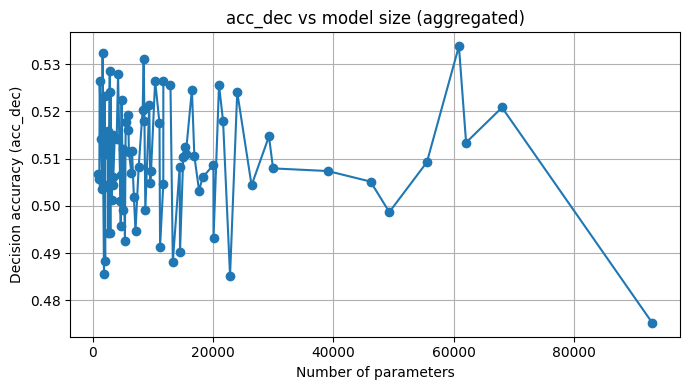

,params,acc_dec,precision_dec,recall_dec,f1_dec
0,871,0.5068,0.5076,0.9953,0.6708
1,1111,0.5056,0.5050,0.9928,0.6688
2,1167,0.5265,0.5298,1.0000,0.6913
3,1407,0.5142,0.5163,0.9978,0.6793
4,1591,0.5037,0.5055,0.9976,0.6701
5,1655,0.5324,0.5334,0.9959,0.6927
6,1759,0.5046,0.5042,0.9934,0.6679
7,1887,0.4855,0.4860,0.9949,0.6509
8,1999,0.5232,0.5249,0.9974,0.6859
9,2079,0.4883,0.4887,0.9949,0.6536


In [10]:
from pathlib import Path
import re
import pandas as pd
import torch
import matplotlib.pyplot as plt

# =========================
# CONFIG
# =========================
OUTDIR = Path("sweep_from_paths_more_genomes")
COVERAGE = COVERAGE_SWEEP
DEVICE = device

# same grids as training
CHANNEL_GRID = [8,16,32, 64]
GCN_HIDDEN_GRID = [8,16,32,64,128,256]
EDGE_HIDDEN_GRID = [8,16,32,64,128,256]

# =========================
# DISCOVER CHECKPOINTS
# =========================
ckpt_pat = re.compile(
    r"emb(?P<ch>\d+)_g(?P<gh>\d+)_e(?P<eh>\d+)"
    r"_cov(?P<cov>\d+)_fold(?P<fold>\d+)_(?P<genome>.+)_rep(?P<rep>\d+)\.pth"
)

records = []
for ckpt in OUTDIR.glob("*.pth"):
    m = ckpt_pat.match(ckpt.name)
    if not m:
        continue
    d = m.groupdict()
    if int(d["cov"]) != COVERAGE:
        continue
    records.append({
        "ckpt": ckpt,
        "cnn_channels": int(d["ch"]),
        "gcn_hidden": int(d["gh"]),
        "edge_hidden": int(d["eh"]),
        "fold": int(d["fold"]),
        "test_genome": d["genome"],
        "repeat": int(d["rep"]),
    })

runs = pd.DataFrame(records)
assert len(runs) > 0, "No checkpoints found"

# =========================
# EVALUATION
# =========================
rows = []

for r in runs.itertuples(index=False):

    variant = f"emb{r.cnn_channels}_g{r.gcn_hidden}_e{r.edge_hidden}"

    def build_model():
        return HyperbubbleGNN(
            vocab_size=6,
            cnn_channels=r.cnn_channels,
            gcn_hidden=r.gcn_hidden,
            edge_hidden=r.edge_hidden,
            edge_feat_dim=4,
            dropout=dropout,
            dropedge_p=edge_dropout,
        )

    # param count (once per variant)
    model_tmp = build_model()
    params = count_params(model_tmp)
    del model_tmp

    # build test dataset
    test_paths = [GENOME_TO_PATH[r.test_genome]]
    test_full = HyperbubbleDataset(test_paths)
    test_lab = labeled_subset(test_full)

    if len(test_lab) == 0:
        print(f"[SKIP] no labels for {r.test_genome}")
        continue

    test_loader = DataLoader(
        test_lab,
        batch_size=BATCH_SIZE,
        shuffle=False,
        num_workers=NUM_WORKERS,
    )

    # load model
    model = build_model().to(DEVICE)
    model.load_state_dict(
        torch.load(r.ckpt, map_location=DEVICE, weights_only=True)
    )

    model.eval()

    with torch.no_grad():
        stats = eval_rich_metrics(model, test_loader, DEVICE)

    stats.update({
        "variant": variant,
        "params": params,
        "fold": r.fold,
        "test_genome": r.test_genome,
        "repeat": r.repeat,
        "coverage": COVERAGE,
    })

    rows.append(stats)

df_raw = pd.DataFrame(rows)

raw_out = OUTDIR / "sweep_results_reconstructed.csv"
df_raw.to_csv(raw_out, index=False)
print(f"[OK] Saved reconstructed results → {raw_out}")

# =========================
# AGGREGATION
# =========================
METRICS = ["acc_dec", "precision_dec", "recall_dec", "f1_dec"]

agg = (
    df_raw
    .groupby("params")[METRICS]
    .mean()
    .reset_index()
    .sort_values("params")
)

# =========================
# PLOT
# =========================
plt.figure(figsize=(7,4))
plt.plot(agg["params"], agg["acc_dec"], marker="o")
plt.xlabel("Number of parameters")
plt.ylabel("Decision accuracy (acc_dec)")
plt.title("acc_dec vs model size (aggregated)")
plt.grid(True)
plt.tight_layout()
plt.show()

# =========================
# TABLE
# =========================
display(
    agg.style
       .format({m: "{:.4f}" for m in METRICS})
       .set_caption("Mean over all completed runs (5 repeats x 3 genomes)")
)


In [11]:
metric_cols = metrics_cols_from_df(df_raw)

agg_spec = {}
for m in metric_cols:
    agg_spec[m] = ["mean", "std"]

df_agg = (
    df_raw
    .groupby(["variant", "coverage", "fold", "test_genome", "params"], dropna=False)[metric_cols]
    .agg(["mean", "std"])
)

# flatten columns: acc_bub_mean, acc_bub_std, ...
df_agg.columns = [f"{c[0]}_{c[1]}" for c in df_agg.columns.to_flat_index()]
df_agg = df_agg.reset_index()

df_agg["runs"] = (
    df_raw.groupby(["variant", "coverage", "fold", "test_genome", "params"], dropna=False)
          .size()
          .values
)

# sort for readability
sort_key = "acc_bub_mean" if "acc_bub_mean" in df_agg.columns else df_agg.columns[-1]
df_agg = df_agg.sort_values(by=["test_genome", sort_key], ascending=[True, False])

agg_path = OUTDIR / "sweep_results_agg_per_genome.csv"
df_agg.to_csv(agg_path, index=False)
print(f"Saved aggregated: {agg_path}")

# show a clean table (per genome/fold, averaged over repeats)
display_cols = ["variant", "test_genome", "fold", "params", "runs"]
for c in ["acc_bub_mean", "acc_bub_std", "acc_dec_mean", "acc_dec_std", "f1_dec_mean", "f1_dec_std"]:
    if c in df_agg.columns:
        display_cols.append(c)

df_agg_clean = df_agg[display_cols]
df_agg_clean.head(30)

# =========================
# Plot: params vs test accuracy (per test genome)
# =========================
if "acc_bub_mean" in df_agg.columns:
    plt.figure(figsize=(10, 6))
    for genome, sub in df_agg.groupby("test_genome", dropna=False):
        x = sub["params"].to_numpy()
        y = sub["acc_bub_mean"].to_numpy()
        plt.scatter(x, y, alpha=0.85, label=str(genome))

        # optional error bars if std exists
        if "acc_bub_std" in sub.columns:
            yerr = sub["acc_bub_std"].fillna(0.0).to_numpy()
            plt.errorbar(x, y, yerr=yerr, fmt="none", alpha=0.35)

    plt.xscale("log")  # useful when params vary a lot
    plt.xlabel("Number of parameters (log scale)")
    plt.ylabel("Test accuracy acc_bub (mean over repeats)")
    plt.title(f"Model size vs test accuracy per genome (coverage={COVERAGE_SWEEP}, repeats={N_REPEATS})")
    plt.legend(bbox_to_anchor=(1.02, 1), loc="upper left", borderaxespad=0.0)
    plt.tight_layout()

    fig_path = OUTDIR / "params_vs_acc_bub_per_genome.png"
    plt.savefig(fig_path, dpi=200)
    print(f"Saved plot: {fig_path}")
    plt.show()
else:
    print("[WARN] acc_bub_mean not found in aggregated results; plot skipped.")

NameError: name 'metrics_cols_from_df' is not defined

## Experiment - augmentation

In [ ]:
def discover_augmented_files(coverage: int = 20):
    """
    Find:
      {genome}_dataset_cov20_ratio_lt_1.5.jsonl          -> original (test)
      {genome}_dataset_cov20_ratio_lt_1.5.train.jsonl    -> train
      {genome}_dataset_cov20_ratio_lt_1.5.test.jsonl     -> val

    Returns:
      { genome: { "orig": Path, "train": Path, "val": Path } }
    """
    base_pat  = f"*dataset_cov{coverage}_ratio_lt_1.5.jsonl"
    train_pat = f"*dataset_cov{coverage}_ratio_lt_1.5.train.jsonl"
    val_pat   = f"*dataset_cov{coverage}_ratio_lt_1.5.test.jsonl"

    files = {}

    for d in SEARCH_DIRS:
        if not d.is_dir():
            continue

        for p in d.glob(base_pat):
            if p.name.endswith(".train.jsonl") or p.name.endswith(".test.jsonl"):
                continue
            genome = p.name.split("_dataset_cov")[0]
            files.setdefault(genome, {})["orig"] = p.resolve()

        for p in d.glob(train_pat):
            genome = p.name.split("_dataset_cov")[0]
            files.setdefault(genome, {})["train"] = p.resolve()

        for p in d.glob(val_pat):
            genome = p.name.split("_dataset_cov")[0]
            files.setdefault(genome, {})["val"] = p.resolve()

    # sanity check
    for g, d in files.items():
        if set(d.keys()) != {"orig", "train", "val"}:
            raise FileNotFoundError(f"Missing orig/train/val for genome {g}")

    return files


GENOME_TO_FILES = discover_augmented_files(20)

In [ ]:
OUTDIR = Path("augment_more_genomes")
OUTDIR.mkdir(exist_ok=True, parents=True)

# Experiment hyperparameters
SEED = 42
BATCH_SIZE = 64
NUM_WORKERS = 0
EPOCHS = 200
PATIENCE = 50
LR = 3e-4
WEIGHT_DECAY = 1e-4

# Architecture sweep grids
CHANNEL_GRID = [32]
GCN_HIDDEN_GRID = [64]
EDGE_HIDDEN_GRID = [64]

dropout = 0.1
edge_dropout = 0.2

PRINT_EVERY = 1

# Coverage sweep (we only use coverage 20 here)
COVERAGE_SWEEP = 20

# GENOME_TO_FILES = { genome_id: { "train": Path, "val": Path } }
GENOME_TO_PATH = GENOME_TO_FILES
GENOMES = sorted(GENOME_TO_PATH.keys())

print("Genomes used for architecture sweep:", GENOMES)

# Ensure OUTDIR again (safe)
OUTDIR.mkdir(parents=True, exist_ok=True)

Genomes used for architecture sweep: ['Citrobacter', 'Cronobacter', 'Ecoli', 'Klebsiella', 'Morganella', 'Proteus', 'Salmonella', 'Serratia']



=== Fold 1: test genome = Citrobacter ===
[Fold 1] train=7000 val=133 test=72
[ep 001] train_loss=0.6968  val_loss=0.6979  val_dec=0.5034
[ep 002] train_loss=0.6762  val_loss=0.6992  val_dec=0.5241
[ep 003] train_loss=0.6596  val_loss=0.7060  val_dec=0.5310
[ep 004] train_loss=0.6361  val_loss=0.7131  val_dec=0.5448
[ep 005] train_loss=0.6166  val_loss=0.7293  val_dec=0.5379
[ep 006] train_loss=0.5970  val_loss=0.7368  val_dec=0.5517
[ep 007] train_loss=0.5802  val_loss=0.7639  val_dec=0.5241
[ep 008] train_loss=0.5663  val_loss=0.7649  val_dec=0.5310
[ep 009] train_loss=0.5559  val_loss=0.7616  val_dec=0.5379
[ep 010] train_loss=0.5457  val_loss=0.7631  val_dec=0.5379
[ep 011] train_loss=0.5280  val_loss=0.7786  val_dec=0.5517
[ep 012] train_loss=0.5175  val_loss=0.7864  val_dec=0.5241
[ep 013] train_loss=0.5035  val_loss=0.7801  val_dec=0.5793
[ep 014] train_loss=0.4877  val_loss=0.7874  val_dec=0.5517
[ep 015] train_loss=0.4792  val_loss=0.7968  val_dec=0.5448
[ep 016] train_loss=0

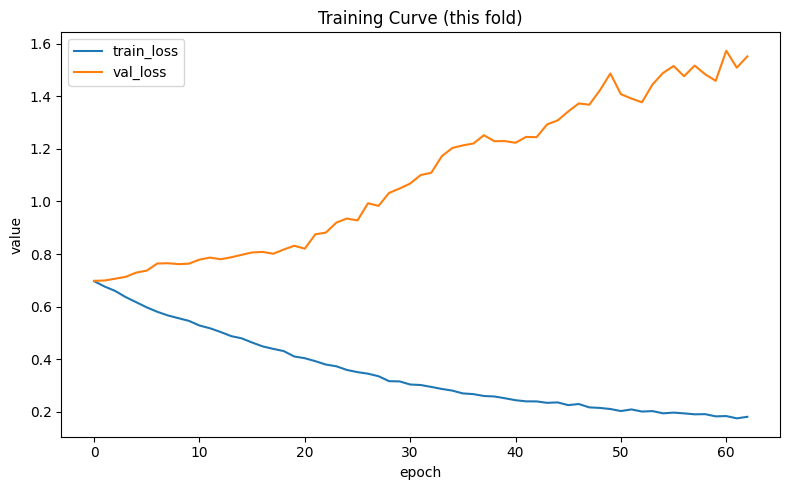

[TEST] fold=1, G=Citrobacter: acc_bub=0.556, acc_dec=0.575, F1_dec=0.730

=== Fold 2: test genome = Cronobacter ===
[Fold 2] train=7000 val=135 test=54
[ep 001] train_loss=0.6971  val_loss=0.6928  val_dec=0.5510
[ep 002] train_loss=0.6792  val_loss=0.6954  val_dec=0.5374
[ep 003] train_loss=0.6601  val_loss=0.6970  val_dec=0.5238
[ep 004] train_loss=0.6365  val_loss=0.6998  val_dec=0.5170
[ep 005] train_loss=0.6226  val_loss=0.7062  val_dec=0.5442
[ep 006] train_loss=0.6066  val_loss=0.7129  val_dec=0.5442
[ep 007] train_loss=0.5935  val_loss=0.7102  val_dec=0.5510
[ep 008] train_loss=0.5773  val_loss=0.7039  val_dec=0.5578
[ep 009] train_loss=0.5674  val_loss=0.7128  val_dec=0.5510
[ep 010] train_loss=0.5461  val_loss=0.7188  val_dec=0.5782
[ep 011] train_loss=0.5417  val_loss=0.7128  val_dec=0.5714
[ep 012] train_loss=0.5269  val_loss=0.7048  val_dec=0.5918
[ep 013] train_loss=0.5147  val_loss=0.6908  val_dec=0.6190
[ep 014] train_loss=0.5022  val_loss=0.6936  val_dec=0.6190
[ep 015]

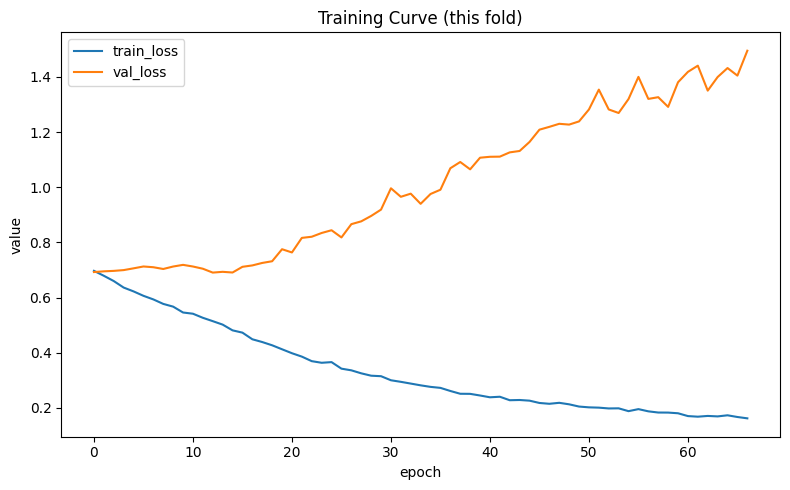

[TEST] fold=2, G=Cronobacter: acc_bub=0.519, acc_dec=0.563, F1_dec=0.721

=== Fold 3: test genome = Ecoli ===
[Fold 3] train=7000 val=120 test=207
[ep 001] train_loss=0.6924  val_loss=0.6906  val_dec=0.5496
[ep 002] train_loss=0.6659  val_loss=0.6909  val_dec=0.5725
[ep 003] train_loss=0.6420  val_loss=0.6895  val_dec=0.5573
[ep 004] train_loss=0.6194  val_loss=0.6916  val_dec=0.5496
[ep 005] train_loss=0.6002  val_loss=0.6992  val_dec=0.5191
[ep 006] train_loss=0.5815  val_loss=0.7037  val_dec=0.5420
[ep 007] train_loss=0.5618  val_loss=0.7122  val_dec=0.5344
[ep 008] train_loss=0.5495  val_loss=0.7068  val_dec=0.5878
[ep 009] train_loss=0.5327  val_loss=0.7087  val_dec=0.5802
[ep 010] train_loss=0.5204  val_loss=0.7200  val_dec=0.5725
[ep 011] train_loss=0.5091  val_loss=0.7189  val_dec=0.5496
[ep 012] train_loss=0.4931  val_loss=0.7239  val_dec=0.5802
[ep 013] train_loss=0.4727  val_loss=0.7249  val_dec=0.5954
[ep 014] train_loss=0.4582  val_loss=0.7211  val_dec=0.5878
[ep 015] trai

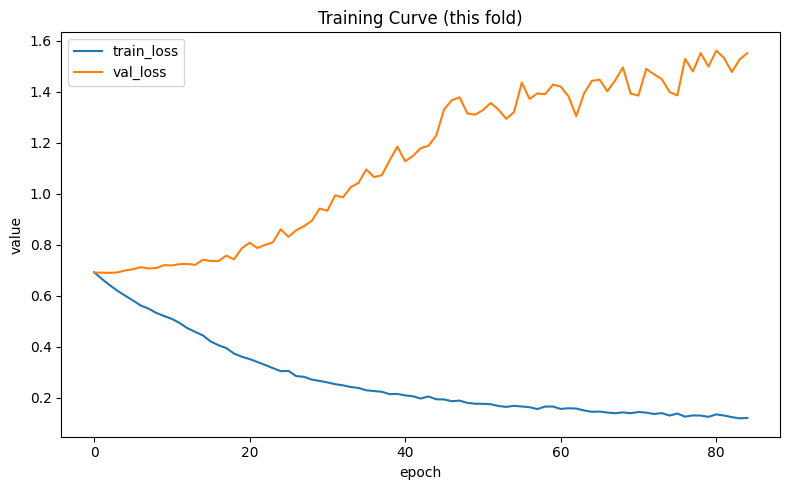

[TEST] fold=3, G=Ecoli: acc_bub=0.415, acc_dec=0.444, F1_dec=0.615

=== Fold 4: test genome = Klebsiella ===
[Fold 4] train=7000 val=125 test=152
[ep 001] train_loss=0.6938  val_loss=0.6998  val_dec=0.4855
[ep 002] train_loss=0.6674  val_loss=0.7005  val_dec=0.5000
[ep 003] train_loss=0.6487  val_loss=0.7052  val_dec=0.5072
[ep 004] train_loss=0.6227  val_loss=0.7120  val_dec=0.5072
[ep 005] train_loss=0.6005  val_loss=0.7155  val_dec=0.5290
[ep 006] train_loss=0.5857  val_loss=0.7197  val_dec=0.5652
[ep 007] train_loss=0.5657  val_loss=0.7143  val_dec=0.5942
[ep 008] train_loss=0.5553  val_loss=0.7065  val_dec=0.6304
[ep 009] train_loss=0.5345  val_loss=0.7155  val_dec=0.5870
[ep 010] train_loss=0.5224  val_loss=0.7277  val_dec=0.5942
[ep 011] train_loss=0.5014  val_loss=0.7204  val_dec=0.5652
[ep 012] train_loss=0.4898  val_loss=0.7177  val_dec=0.5942
[ep 013] train_loss=0.4732  val_loss=0.7070  val_dec=0.6087
[ep 014] train_loss=0.4612  val_loss=0.7127  val_dec=0.5797
[ep 015] train

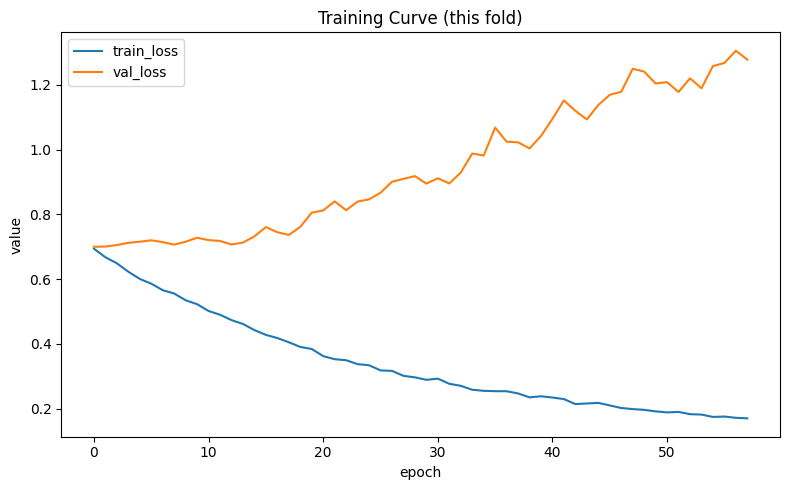

[TEST] fold=4, G=Klebsiella: acc_bub=0.461, acc_dec=0.494, F1_dec=0.664

=== Fold 5: test genome = Morganella ===
[Fold 5] train=7000 val=105 test=359
[ep 001] train_loss=0.6932  val_loss=0.6932  val_dec=0.5339
[ep 002] train_loss=0.6658  val_loss=0.6997  val_dec=0.5424
[ep 003] train_loss=0.6437  val_loss=0.7060  val_dec=0.5678
[ep 004] train_loss=0.6200  val_loss=0.7160  val_dec=0.5424
[ep 005] train_loss=0.5963  val_loss=0.7263  val_dec=0.5254
[ep 006] train_loss=0.5762  val_loss=0.7336  val_dec=0.5169
[ep 007] train_loss=0.5568  val_loss=0.7398  val_dec=0.5000
[ep 008] train_loss=0.5428  val_loss=0.7457  val_dec=0.5169
[ep 009] train_loss=0.5249  val_loss=0.7459  val_dec=0.5085
[ep 010] train_loss=0.5128  val_loss=0.7786  val_dec=0.5085
[ep 011] train_loss=0.4968  val_loss=0.7748  val_dec=0.5593
[ep 012] train_loss=0.4768  val_loss=0.7780  val_dec=0.5169
[ep 013] train_loss=0.4669  val_loss=0.8025  val_dec=0.4915
[ep 014] train_loss=0.4470  val_loss=0.8063  val_dec=0.5085
[ep 015] 

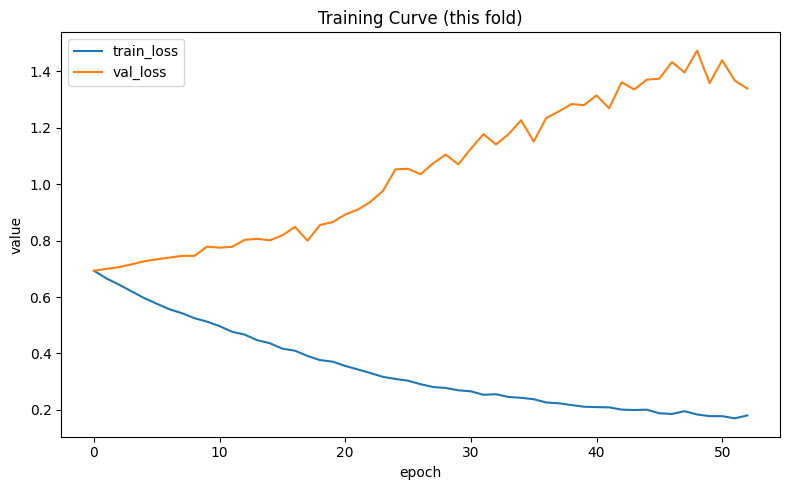

[TEST] fold=5, G=Morganella: acc_bub=0.501, acc_dec=0.525, F1_dec=0.689

=== Fold 6: test genome = Proteus ===
[Fold 6] train=7000 val=131 test=91
[ep 001] train_loss=0.6925  val_loss=0.7021  val_dec=0.5108
[ep 002] train_loss=0.6706  val_loss=0.7043  val_dec=0.5252
[ep 003] train_loss=0.6531  val_loss=0.7096  val_dec=0.5252
[ep 004] train_loss=0.6331  val_loss=0.7127  val_dec=0.5036
[ep 005] train_loss=0.6144  val_loss=0.7169  val_dec=0.5180
[ep 006] train_loss=0.6017  val_loss=0.7193  val_dec=0.5252
[ep 007] train_loss=0.5858  val_loss=0.7206  val_dec=0.5180
[ep 008] train_loss=0.5733  val_loss=0.7355  val_dec=0.5396
[ep 009] train_loss=0.5658  val_loss=0.7384  val_dec=0.5612
[ep 010] train_loss=0.5521  val_loss=0.7374  val_dec=0.5612
[ep 011] train_loss=0.5374  val_loss=0.7336  val_dec=0.5612
[ep 012] train_loss=0.5283  val_loss=0.7387  val_dec=0.5612
[ep 013] train_loss=0.5096  val_loss=0.7408  val_dec=0.5683
[ep 014] train_loss=0.4995  val_loss=0.7658  val_dec=0.5827
[ep 015] trai

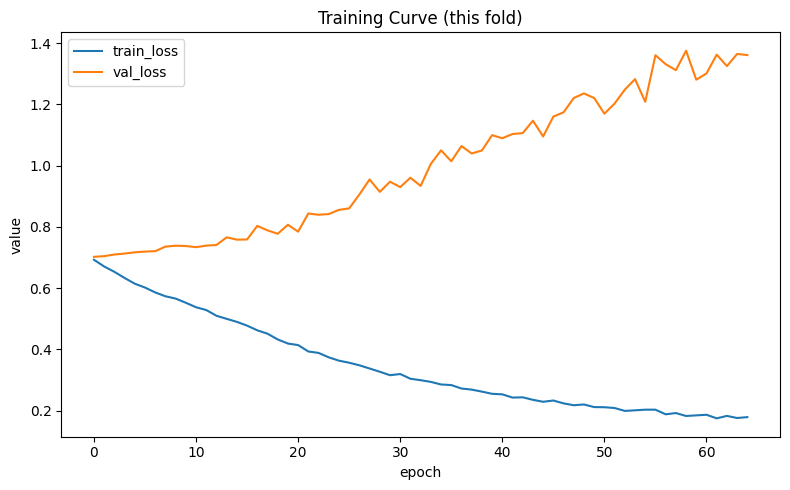

[TEST] fold=6, G=Proteus: acc_bub=0.374, acc_dec=0.467, F1_dec=0.640

=== Fold 7: test genome = Salmonella ===
[Fold 7] train=7000 val=115 test=259
[ep 001] train_loss=0.6926  val_loss=0.6961  val_dec=0.4841
[ep 002] train_loss=0.6649  val_loss=0.7023  val_dec=0.5159
[ep 003] train_loss=0.6417  val_loss=0.7193  val_dec=0.5079
[ep 004] train_loss=0.6165  val_loss=0.7255  val_dec=0.5238
[ep 005] train_loss=0.5948  val_loss=0.7390  val_dec=0.5556
[ep 006] train_loss=0.5759  val_loss=0.7354  val_dec=0.5238
[ep 007] train_loss=0.5524  val_loss=0.7415  val_dec=0.5317
[ep 008] train_loss=0.5436  val_loss=0.7427  val_dec=0.5397
[ep 009] train_loss=0.5300  val_loss=0.7451  val_dec=0.5079
[ep 010] train_loss=0.5141  val_loss=0.7319  val_dec=0.5159
[ep 011] train_loss=0.4995  val_loss=0.7554  val_dec=0.5397
[ep 012] train_loss=0.4787  val_loss=0.7652  val_dec=0.5476
[ep 013] train_loss=0.4621  val_loss=0.7606  val_dec=0.5556
[ep 014] train_loss=0.4505  val_loss=0.7869  val_dec=0.5159
[ep 015] tra

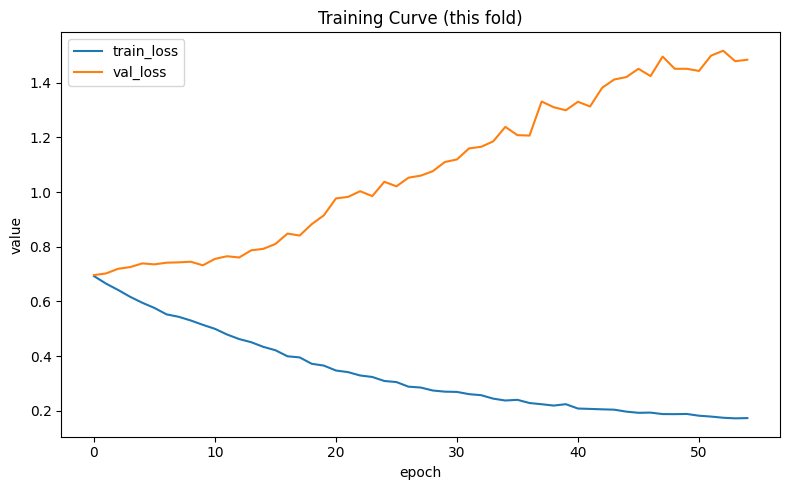

[TEST] fold=7, G=Salmonella: acc_bub=0.467, acc_dec=0.502, F1_dec=0.670

=== Fold 8: test genome = Serratia ===
[Fold 8] train=7000 val=123 test=171
[ep 001] train_loss=0.6947  val_loss=0.6922  val_dec=0.5075
[ep 002] train_loss=0.6645  val_loss=0.6939  val_dec=0.5448
[ep 003] train_loss=0.6435  val_loss=0.7089  val_dec=0.5373
[ep 004] train_loss=0.6239  val_loss=0.7237  val_dec=0.5597
[ep 005] train_loss=0.6044  val_loss=0.7287  val_dec=0.5448
[ep 006] train_loss=0.5789  val_loss=0.7417  val_dec=0.5522
[ep 007] train_loss=0.5668  val_loss=0.7434  val_dec=0.5597
[ep 008] train_loss=0.5541  val_loss=0.7468  val_dec=0.5672
[ep 009] train_loss=0.5317  val_loss=0.7610  val_dec=0.5896
[ep 010] train_loss=0.5207  val_loss=0.7657  val_dec=0.5672
[ep 011] train_loss=0.5030  val_loss=0.7654  val_dec=0.5373
[ep 012] train_loss=0.4975  val_loss=0.7743  val_dec=0.5448
[ep 013] train_loss=0.4856  val_loss=0.7598  val_dec=0.5224
[ep 014] train_loss=0.4739  val_loss=0.7732  val_dec=0.5149
[ep 015] tr

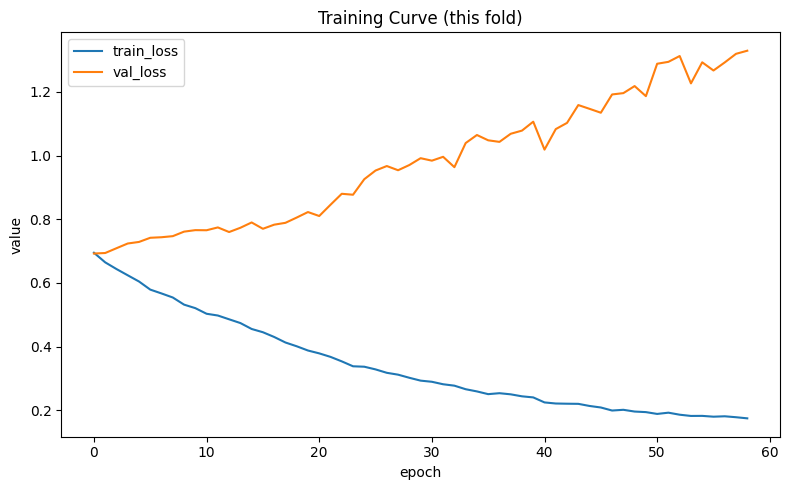

[TEST] fold=8, G=Serratia: acc_bub=0.520, acc_dec=0.545, F1_dec=0.706
Saved results to augment_more_genomes\results.csv


,acc_dec,acc_bub,precision_dec,recall_dec,f1_dec,brier,decisions,bubbles,fold,test_genome,params
0,0.574713,0.555556,0.574713,1.0,0.729927,0.142771,87,72,1,Citrobacter,26399
1,0.563380,0.518519,0.563380,1.0,0.720721,0.110345,71,54,2,Cronobacter,26399
2,0.444444,0.415459,0.444444,1.0,0.615385,0.077537,234,207,3,Ecoli,26399
3,0.494186,0.460526,0.497076,1.0,0.664062,0.183678,172,152,4,Klebsiella,26399
4,0.525126,0.501393,0.525126,1.0,0.688633,0.210744,398,359,5,Morganella,26399


In [ ]:
rows = []
set_seed(SEED)

def build_model():
    return HyperbubbleGNN(
        vocab_size=6,
        cnn_channels=CHANNEL_GRID[0],
        gcn_hidden=GCN_HIDDEN_GRID[0],
        edge_hidden=EDGE_HIDDEN_GRID[0],
        edge_feat_dim=4,
        dropout=dropout,
        dropedge_p=edge_dropout
    )

for fold, test_genome in enumerate(GENOMES, start=1):
    print(f"\n=== Fold {fold}: test genome = {test_genome} ===")

    test_path = GENOME_TO_FILES[test_genome]["orig"]
    test_full = HyperbubbleDataset([test_path])
    test_lab  = labeled_subset(test_full)

    if len(test_lab) == 0:
        print(f"[WARN] No labels for test genome {test_genome}, skipping fold.")
        continue

    test_ds = test_lab

    # --- TRAIN + VAL from other genomes ---
    other_genomes = [g for g in GENOMES if g != test_genome]

    train_paths = [GENOME_TO_FILES[g]["train"] for g in other_genomes]
    val_paths   = [GENOME_TO_FILES[g]["val"]   for g in other_genomes]

    train_full = HyperbubbleDataset(train_paths)
    val_full   = HyperbubbleDataset(val_paths)

    train_lab = labeled_subset(train_full)
    val_lab   = labeled_subset(val_full)

    if len(train_lab) == 0 or len(val_lab) == 0:
        print(f"[WARN] Empty train/val for fold {fold}, skipping.")
        continue

    train_ds = train_lab
    val_ds   = val_lab

    train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True, num_workers=NUM_WORKERS)
    val_loader   = DataLoader(val_ds,   batch_size=BATCH_SIZE, shuffle=False, num_workers=NUM_WORKERS)
    test_loader  = DataLoader(test_ds,  batch_size=BATCH_SIZE, shuffle=False, num_workers=NUM_WORKERS)

    print(f"[Fold {fold}] train={len(train_ds)} val={len(val_ds)} test={len(test_ds)}")

    # --- Train ---
    ckpt    = OUTDIR / f"best_fold{fold}_{test_genome}.pth"
    log_csv = OUTDIR / f"history_fold{fold}_{test_genome}.csv"

    best_state, hist_df = fit_variant(
        build_model_fn=build_model,
        train_loader=train_loader,
        val_loader=val_loader,
        device=device,
        out_ckpt=ckpt,
        epochs=EPOCHS,
        lr=LR,
        weight_decay=WEIGHT_DECAY,
        patience=PATIENCE,
        seed=SEED,
        print_every=PRINT_EVERY,
        early_stop=True,
    )

    hist_df["fold"]        = fold
    hist_df["test_genome"] = test_genome
    hist_df.to_csv(log_csv, index=False)

    # --- Eval ---
    model = build_model().to(device)
    model.load_state_dict(best_state)
    model.eval()

    stats = eval_rich_metrics(model, test_loader, device)
    stats["fold"] = fold
    stats["test_genome"] = test_genome
    stats["params"] = count_params(model)
    rows.append(stats)

    print(f"[TEST] fold={fold}, G={test_genome}: "
          f"acc_bub={stats['acc_bub']:.3f}, "
          f"acc_dec={stats['acc_dec']:.3f}, "
          f"F1_dec={stats['f1_dec']:.3f}"
    )

df = pd.DataFrame(rows)
df_path = OUTDIR / "results.csv"
df.to_csv(df_path, index=False)
print(f"Saved results to {df_path}")
df.head()